
**Metryka Zysku:**
- Bank dostaje $0.3\%$ rocznych zarobków (`EstimatedSalary`).
- Bank może zaoferować zniżkę, za co dostaje $0.1\%$ rocznych zarobków.
- Jeśli klient odejdzie bez zniżki, bank nie zarabia nic.


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')



## Wczytanie Danych


In [49]:
df = pd.read_csv('Customer-Churn-Records.csv')
display(df.head())
display(df.info())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  str    
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  str    
 5   Gender              10000 non-null  str    
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card Type       

None

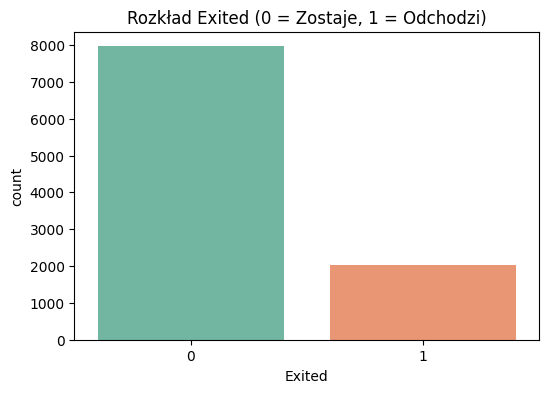

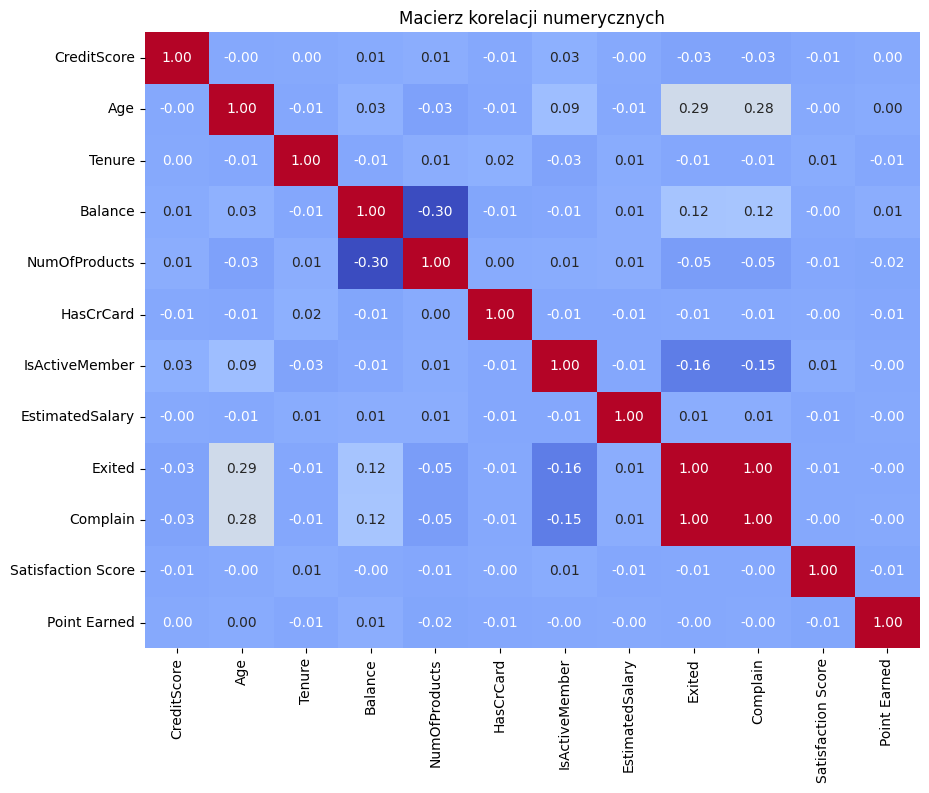

In [50]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Exited', palette='Set2')
plt.title('Rozkład Exited (0 = Zostaje, 1 = Odchodzi)')
plt.show()

numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(['RowNumber', 'CustomerId'])
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', cbar=False)
plt.title('Macierz korelacji numerycznych')
plt.show()



## Metryka biznesowa - zysk banku
- TP i FP: dajemy zniżkę. Zysk = `0.001 * EstimatedSalary`
- TN: nie dajemy zniżki, klient zostaje. Zysk = `0.003 * EstimatedSalary`
- FN: nie dajemy zniżki, klient odchodzi. Zysk = `0`


In [51]:

def calculate_profit(y_true, y_pred, salaries):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    salaries = np.array(salaries)
    
    profit = 0.0
    for true, pred, salary in zip(y_true, y_pred, salaries):
        if pred == 1:
            profit += 0.001 * salary
        else:
            if true == 0:
                profit += 0.003 * salary
            else:
                profit += 0.0
    return profit


## Preprocessing i Pipeline
- Usuwamy: `RowNumber`, `CustomerId`, `Surname`
- Kategoryczne (`Geography`, `Gender`, `Card Type`) -> OneHotEncoder
- Numeryczne -> StandardScaler


In [52]:
X = df.drop(columns=['Exited', 'RowNumber', 'CustomerId', 'Surname', 'Complain'])
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

num_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Satisfaction Score', 'Point Earned']
cat_features = ['Geography', 'Gender', 'Card Type']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(f_classif, k=7)),
    ('knn', KNeighborsClassifier())
])


## Optymalizacja


In [56]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'knn__n_neighbors': [31, 41, 51, 53, 55, 57, 59, 61, 71, 91, 111, 151, 201],
    'knn__weights': ['uniform', 'distance']
}

print("Walidacja krzyżowa...")
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=1
)

grid_search.fit(X_train, y_train)

print(f"Najlepsze znalezione parametry: {grid_search.best_params_}")
print(f"Najlepszy wynik (ROC AUC) w CV: {grid_search.best_score_:.3f}")

best_model = grid_search.best_estimator_


Walidacja krzyżowa...
Najlepsze znalezione parametry: {'knn__n_neighbors': 51, 'knn__weights': 'uniform'}
Najlepszy wynik (ROC AUC) w CV: 0.850



## Ewaluacja i Podsumowanie Zysku
Porówmnanie zysków z podejściami naiwnymi

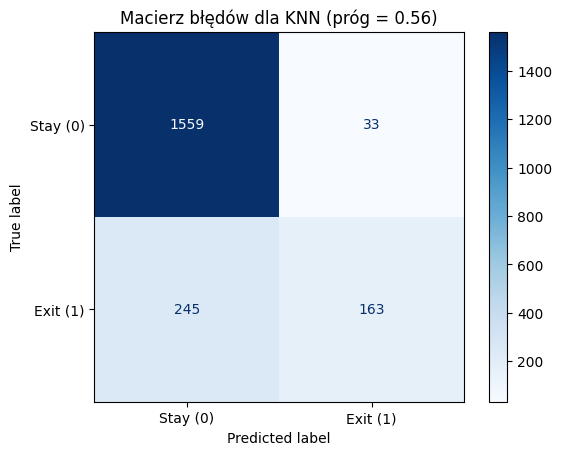

=== PODSUMOWANIE ZYSKÓW NA ZBIORZE TESTOWYM (PRÓG ZOPTYMALIZOWANY) ===
Baza (Nikomu zniżki):      490,167.43 USD
Baza (wszystkim zniżkę):   204,746.39 USD
Zysk Modelu KNN (max):     499,402.10 USD
Zysk Idealnego Modelu:     531,524.67 USD

Model przynosi ZYSK 9,234.67 USD w porównaniu do naiwnych strategii.


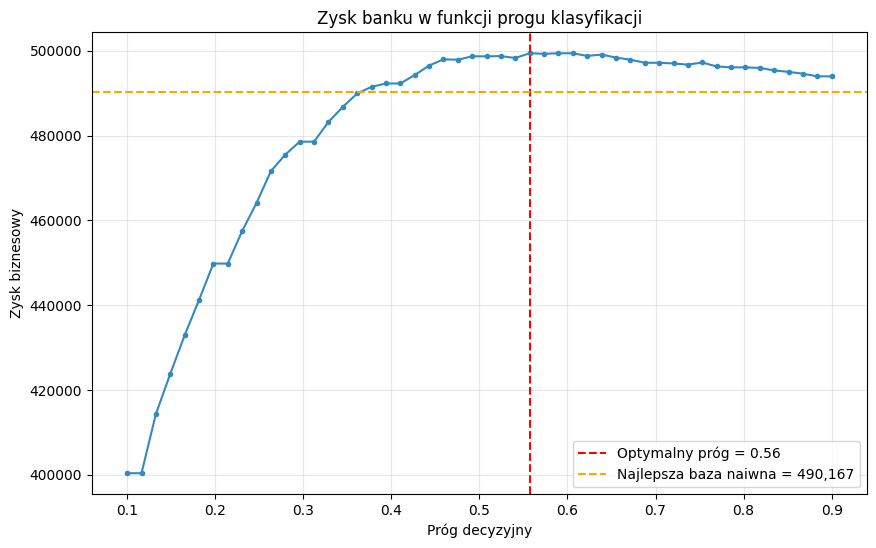

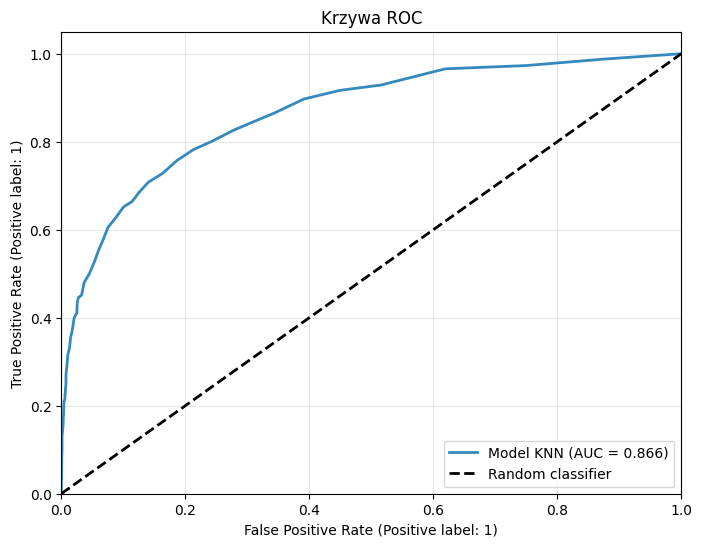

In [59]:

from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

y_prob = best_model.predict_proba(X_test)[:, 1]
salaries_test = X_test['EstimatedSalary'].values

thresholds_to_test = np.linspace(0.1, 0.9, 50)
profits = []

for t in thresholds_to_test:
    y_pred_t = (y_prob >= t).astype(int)
    profit_t = calculate_profit(y_test, y_pred_t, salaries_test)
    profits.append(profit_t)

opt_idx_val = np.argmax(profits)
opt_threshold = thresholds_to_test[opt_idx_val]
max_profit = profits[opt_idx_val]

y_pred_opt = (y_prob >= opt_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay (0)', 'Exit (1)'])
disp.plot(cmap='Blues')
plt.title(f'Macierz błędów dla KNN (próg = {opt_threshold:.2f})')
plt.show()

profit_baseline_0 = calculate_profit(y_test, [0]*len(y_test), salaries_test)
profit_baseline_1 = calculate_profit(y_test, [1]*len(y_test), salaries_test)
profit_ideal = calculate_profit(y_test, y_test, salaries_test)
best_baseline = max(profit_baseline_0, profit_baseline_1)

print("=== PODSUMOWANIE ZYSKÓW NA ZBIORZE TESTOWYM (PRÓG ZOPTYMALIZOWANY) ===")
print(f"Baza (Nikomu zniżki):      {profit_baseline_0:,.2f} USD")
print(f"Baza (wszystkim zniżkę):   {profit_baseline_1:,.2f} USD")
print(f"Zysk Modelu KNN (max):     {max_profit:,.2f} USD")
print(f"Zysk Idealnego Modelu:     {profit_ideal:,.2f} USD")

gain = max_profit - best_baseline
if gain > 0:
    print(f"\nModel przynosi ZYSK {gain:,.2f} USD w porównaniu do naiwnych strategii.")
else:
    print(f"\nModel generuje STRATĘ {gain:,.2f} USD w porównaniu do lepszej ze strategii naiwnych.")

plt.figure(figsize=(10, 6))
plt.plot(thresholds_to_test, profits, marker='.', color='#348ABD')
plt.axvline(x=opt_threshold, color='red', linestyle='--', label=f'Optymalny próg = {opt_threshold:.2f}')
plt.axhline(y=best_baseline, color='orange', linestyle='--', label=f'Najlepsza baza naiwna = {best_baseline:,.0f}')
plt.title('Zysk banku w funkcji progu klasyfikacji')
plt.xlabel('Próg decyzyjny')
plt.ylabel('Zysk biznesowy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#348ABD', lw=2, label=f'Model KNN (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Positive label: 1)')
plt.ylabel('True Positive Rate (Positive label: 1)')
plt.title('Krzywa ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()



## Wyniki i wizualizacje


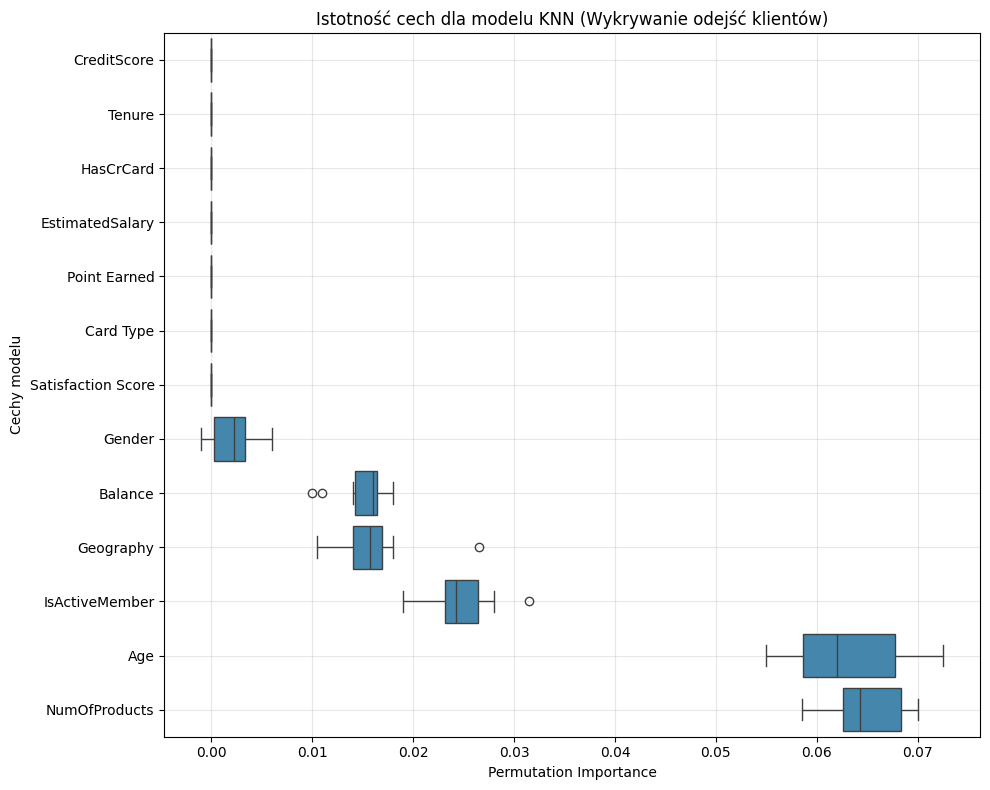

In [60]:
from sklearn.inspection import permutation_importance

result = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

feature_names = X_test.columns.to_numpy()

sorted_idx = result.importances_mean.argsort()

plt.figure(figsize=(10, 8))
sns.boxplot(data=result.importances[sorted_idx].T, orient='h', color='#348ABD')

plt.yticks(ticks=range(len(feature_names)), labels=feature_names[sorted_idx])
plt.xlabel("Permutation Importance")
plt.ylabel("Cechy modelu")
plt.title("Istotność cech dla modelu KNN (Wykrywanie odejść klientów)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
